**Part 1: House Price Prediction**

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


# Data source:
# https://www.kaggle.com/datasets/fratzcan/usa-house-prices/data

# Load the real housing dataset
df = pd.read_csv("USA Housing Dataset.csv")


# Keep only the columns needed
df = df[['price', 'sqft_living', 'city']].copy()

# Remove houses with a price of 0
df = df[df['price'] > 0].copy()

# Rename
df = df.rename(columns={'sqft_living': 'square_footage'})


# Simplified location categories
# Seattle is treated as Downtown, surrounding metro cities as Suburb,
# and the remaining smaller towns as Rural.
suburban_cities = {
    'Bellevue', 'Redmond', 'Kirkland', 'Renton', 'Kent',
    'Federal Way', 'Shoreline', 'Bothell', 'Sammamish',
    'Issaquah', 'Mercer Island', 'Newcastle', 'Burien',
    'SeaTac', 'Tukwila', 'Des Moines', 'Kenmore',
    'Lake Forest Park', 'Normandy Park', 'Clyde Hill',
    'Medina', 'Yarrow Point', 'Beaux Arts Village',
    'Woodinville', 'Auburn', 'Covington', 'Maple Valley'
}


def classify_location(city):
    if city == 'Seattle':
        return 'Downtown'
    elif city in suburban_cities:
        return 'Suburb'
    else:
        return 'Rural'


df['location'] = df['city'].apply(classify_location)


# Features and target
X = df[['square_footage', 'location']]
y = df['price']


# One-hot encode the categorical location feature.
# Downtown is dropped and becomes the baseline category.
preprocessor = ColumnTransformer(
    transformers=[
        (
            'location',
            OneHotEncoder(
                categories=[['Downtown', 'Rural', 'Suburb']],
                drop='first',
                sparse_output=False
            ),
            ['location']
        )
    ],
    remainder='passthrough'
)


# Create a pipeline containing preprocessing and linear regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Train the model
model.fit(X_train, y_train)


# Evaluate the model on unseen test data
test_predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-squared Score: {r2:.3f}")


# Predict the price of a 2000 sq ft house in Downtown
new_house = pd.DataFrame({
    'square_footage': [2000],
    'location': ['Downtown']
})

predicted_price = model.predict(new_house)

print(
    f"\nPredicted price for a 2000 sq ft house in Downtown: "
    f"${predicted_price[0]:,.2f}"
)


# Get names of the features after preprocessing
location_features = (
    model.named_steps['preprocessor']
    .named_transformers_['location']
    .get_feature_names_out(['location'])
).tolist()

feature_names = location_features + ['square_footage']

# Get the coefficients from the trained linear regression model
coefficients = model.named_steps['regressor'].coef_
intercept = model.named_steps['regressor'].intercept_

print("\nModel Coefficients:")
print(f"Intercept (Downtown baseline): ${intercept:,.2f}")

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:,.2f}")
print("\nCoefficient Interpretation:")

print(
    f"Holding location constant, each additional square foot of living "
    f"space increases the predicted house price by approximately "
    f"${coefficients[-1]:,.2f}."
)

print(
    "Downtown is the baseline location used for comparison."
)

print(
    f"Holding square footage constant, a Rural house is predicted "
    f"to cost approximately ${abs(coefficients[0]):,.2f} less than "
    f"a comparable Downtown house."
)

print(
    f"Holding square footage constant, a Suburban house is predicted "
    f"to cost approximately ${abs(coefficients[1]):,.2f} less than "
    f"a comparable Downtown house."
)

Mean Absolute Error: $162,641.46
R-squared Score: 0.506

Predicted price for a 2000 sq ft house in Downtown: $639,328.42

Model Coefficients:
Intercept (Downtown baseline): $73,609.18
location_Rural: -244,899.78
location_Suburb: -166,829.38
square_footage: 282.86

Coefficient Interpretation:
Holding location constant, each additional square foot of living space increases the predicted house price by approximately $282.86.
Downtown is the baseline location used for comparison.
Holding square footage constant, a Rural house is predicted to cost approximately $244,899.78 less than a comparable Downtown house.
Holding square footage constant, a Suburban house is predicted to cost approximately $166,829.38 less than a comparable Downtown house.


**Part 2 Customer Churn Prediction:**



In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score


# Data source:
# https://www.kaggle.com/datasets/barun2104/telecom-churn

# Load the real telecom churn dataset
df = pd.read_csv("telecom_churn.csv")


# Convert binary categorical columns into readable categories
df["ContractRenewal"] = df["ContractRenewal"].map({
    0: "No",
    1: "Yes"
})

df["DataPlan"] = df["DataPlan"].map({
    0: "No",
    1: "Yes"
})


# Numerical and categorical features
numerical_features = [
    "AccountWeeks",
    "DataUsage",
    "CustServCalls",
    "DayMins",
    "DayCalls",
    "MonthlyCharge",
    "OverageFee",
    "RoamMins"
]

categorical_features = [
    "ContractRenewal",
    "DataPlan"
]


# Features and target
X = df[numerical_features + categorical_features]
y = df["Churn"]


# Preprocessing:
# Standardize numerical features
# One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# Create pipeline with preprocessing and Logistic Regression
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])


# Split data into training and testing sets
# stratify keeps approximately the same churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train the model
model.fit(X_train, y_train)


# Evaluate the model on test data
test_predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, test_predictions)
precision = precision_score(y_test, test_predictions)
recall = recall_score(y_test, test_predictions)

print("Model Evaluation:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")


# Create a new example customer
new_customer = pd.DataFrame({
    "AccountWeeks": [80],
    "DataUsage": [0.0],
    "CustServCalls": [5],
    "DayMins": [250.0],
    "DayCalls": [100],
    "MonthlyCharge": [70.0],
    "OverageFee": [12.0],
    "RoamMins": [12.0],
    "ContractRenewal": ["No"],
    "DataPlan": ["No"]
})


# Predict probability of churn
churn_probability = model.predict_proba(new_customer)[0][1]


# Classify using the required 0.5 threshold
threshold = 0.5

churn_prediction = 1 if churn_probability >= threshold else 0


print(
    f"\nChurn Probability for new customer: "
    f"{churn_probability:.2%}"
)

print(
    f"Churn Prediction "
    f"(1 = churn, 0 = no churn): {churn_prediction}"
)


# Explain the probability and business use
print("\nInterpretation:")

if churn_prediction == 1:
    print(
        f"The customer has a {churn_probability:.1%} predicted chance "
        f"of churning. Because this is above the 0.5 threshold, "
        f"the customer is classified as at risk of churn."
    )

    print(
        "A business could target this customer with retention strategies "
        "such as discounts, improved service, or a renewal offer."
    )

else:
    print(
        f"The customer has a {churn_probability:.1%} predicted chance "
        f"of churning. Because this is below the 0.5 threshold, "
        f"the customer is classified as unlikely to churn."
    )

    print(
        "The business may not need an immediate retention intervention "
        "for this customer."
    )


# Display model coefficients
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Make feature names easier to read
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

coefficients = model.named_steps[
    "classifier"
].coef_[0]

print("\nModel Coefficients:")

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.3f}")

Model Evaluation:
Accuracy: 0.855
Precision: 0.500
Recall: 0.175

Churn Probability for new customer: 95.16%
Churn Prediction (1 = churn, 0 = no churn): 1

Interpretation:
The customer has a 95.2% predicted chance of churning. Because this is above the 0.5 threshold, the customer is classified as at risk of churn.
A business could target this customer with retention strategies such as discounts, improved service, or a renewal offer.

Model Coefficients:
AccountWeeks: 0.035
DataUsage: -0.097
CustServCalls: 0.724
DayMins: 0.495
DayCalls: 0.082
MonthlyCharge: 0.281
OverageFee: 0.287
RoamMins: 0.222
ContractRenewal_Yes: -1.923
DataPlan_Yes: -1.174


**Part 3: Customer Segmentation**

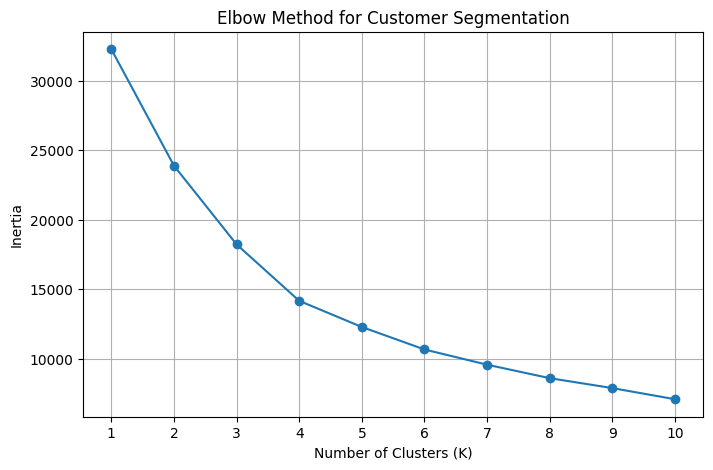


K Selection:
I selected K = 4 because the elbow plot shows a large decrease in inertia from K = 1 through K = 4. After K = 4, the decrease becomes more gradual, suggesting that four clusters provide a reasonable balance without adding unnecessary groups.

Spending Score Mapping:
1 = Low, 2 = Average, 3 = High

Cluster Characteristics:
           Age  Work_Experience  Family_Size  Spending_Score_Num
cluster                                                         
0        28.43             1.13         4.26                1.08
1        49.54             0.97         1.62                1.00
2        53.79             1.18         2.99                2.43
3        36.89             8.44         2.48                1.36

Number of Customers in Each Cluster:
cluster
0    1938
1    2031
2    2590
3    1509
Name: count, dtype: int64

Suggested Marketing Strategies:

Cluster 0:
Larger-family customers: Offer family bundles, discount packages, and value-focused promotions.

Cluster 1:
Lower-s

In [15]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Data source:
# https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation

# Load the real customer segmentation dataset
df = pd.read_csv("train.csv")


# -----------------------------
# Clean and prepare the data
# -----------------------------

# Fill missing numerical values with the median
df["Work_Experience"] = df["Work_Experience"].fillna(
    df["Work_Experience"].median()
)

df["Family_Size"] = df["Family_Size"].fillna(
    df["Family_Size"].median()
)


# Convert Spending_Score into numerical values
# Low = 1, Average = 2, High = 3
spending_mapping = {
    "Low": 1,
    "Average": 2,
    "High": 3
}

df["Spending_Score_Num"] = df["Spending_Score"].map(spending_mapping)


# Select the features used for clustering
# The existing "Segmentation" column is NOT used because
# K-Means is an unsupervised learning algorithm.
features = [
    "Age",
    "Work_Experience",
    "Family_Size",
    "Spending_Score_Num"
]

X = df[features]


# -----------------------------
# Scale numerical features
# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# -----------------------------
# Elbow Method
# -----------------------------

inertia = []

# Test K values from 1 through 10
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


# Plot the elbow curve
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")

plt.xticks(list(K))
plt.grid(True)

# Save the elbow plot
plt.savefig("elbow_plot.png")

# Display the plot
plt.show()


# Explain why K = 4 was selected
print("\nK Selection:")
print(
    "I selected K = 4 because the elbow plot shows a large decrease "
    "in inertia from K = 1 through K = 4. After K = 4, the decrease "
    "becomes more gradual, suggesting that four clusters provide a "
    "reasonable balance without adding unnecessary groups."
)


# -----------------------------
# Apply K-Means
# -----------------------------

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)


# -----------------------------
# Analyze the clusters
# -----------------------------

cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)


# Explain how the spending score was converted
print("\nSpending Score Mapping:")
print("1 = Low, 2 = Average, 3 = High")


# Display cluster averages
print("\nCluster Characteristics:")
print(cluster_summary)


# Show number of customers in each cluster
print("\nNumber of Customers in Each Cluster:")
print(
    df["cluster"]
    .value_counts()
    .sort_index()
)


# -----------------------------
# Marketing Strategies
# -----------------------------

print("\nSuggested Marketing Strategies:")

for cluster, row in cluster_summary.iterrows():

    print(f"\nCluster {cluster}:")

    # Higher-spending customers
    if row["Spending_Score_Num"] >= 2:

        print(
            "Higher-spending customers: Offer loyalty rewards, "
            "exclusive promotions, and premium products."
        )

    # Larger families
    elif row["Family_Size"] >= 3.5:

        print(
            "Larger-family customers: Offer family bundles, "
            "discount packages, and value-focused promotions."
        )

    # More experienced professionals
    elif row["Work_Experience"] >= 5:

        print(
            "Experienced professionals: Promote convenient services, "
            "premium upgrades, and personalized offers."
        )

    # Remaining lower-spending customers
    else:

        print(
            "Lower-spending customers: Use targeted discounts "
            "and re-engagement promotions."
        )


# -----------------------------
# Save cluster results
# -----------------------------

df.to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "\nCluster assignments saved to "
    "'customer_segments.csv'."
)

**Extra Credit**

Historical Data:
        date     home_value  month_number
0 2018-02-01  225746.614318             0
1 2018-03-01  227155.648994             1
2 2018-04-01  228438.629400             2
3 2018-05-01  229684.954925             3
4 2018-06-01  230589.339512             4

Historical period: February 2018 through May 2024
Number of historical months: 76

Estimated average monthly change in home value: $2,141.11

6-Month Housing Price Forecast:
June 2024: $374,080.22
July 2024: $376,221.32
August 2024: $378,362.43
September 2024: $380,503.54
October 2024: $382,644.65
November 2024: $384,785.76


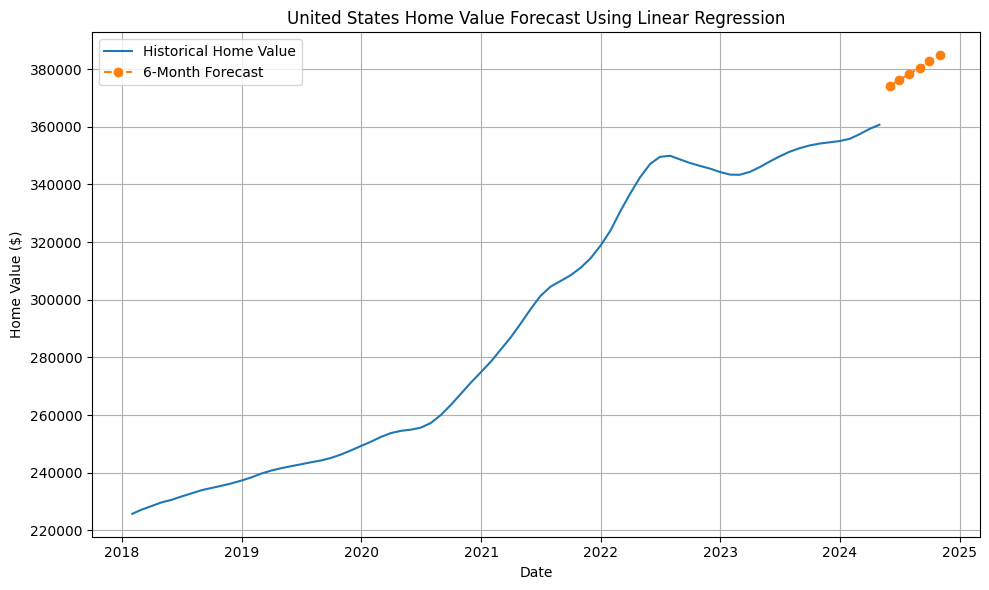


Forecast saved to 'housing_forecast_6_months.csv'.

Assumptions:
1. HomeValue is used as a simplified indicator of housing market trends because this dataset does not contain direct monthly sales or inventory counts.
2. The Linear Regression model assumes that the historical trend will continue approximately linearly during the next six months.
3. The forecast uses national United States data rather than individual regional markets.

Potential Improvements:
1. Include housing inventory and monthly sales data to measure demand more directly.
2. Include other factors such as mortgage rates, interest rates, income, and economic conditions.
3. Use more advanced time-series models to capture seasonality and changing market trends.


In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


# Data source:
# https://www.kaggle.com/datasets/clovisdalmolinvieira/us-housing-trends-values-time-and-price-cuts


# -----------------------------
# Load the dataset
# -----------------------------

df = pd.read_csv("USRealEstateTrends.csv")


# Use the national United States housing data
us_data = df[df["RegionName"] == "United States"].iloc[0]


# -----------------------------
# Prepare historical data
# -----------------------------

# Find all columns containing monthly HomeValue data
home_value_columns = [
    column for column in df.columns
    if column.endswith("-HomeValue")
]


# Convert the wide-format columns into a simpler
# date and home value dataset
historical_data = pd.DataFrame({
    "date": [
        pd.to_datetime(
            column.replace("-HomeValue", ""),
            format="%Y-%m"
        )
        for column in home_value_columns
    ],

    "home_value": [
        us_data[column]
        for column in home_value_columns
    ]
})


# Remove any missing values
historical_data = historical_data.dropna()


# Sort the data by date
historical_data = historical_data.sort_values(
    "date"
).reset_index(drop=True)


# Create a numerical month variable for Linear Regression
historical_data["month_number"] = np.arange(
    len(historical_data)
)


print("Historical Data:")
print(historical_data.head())

print(
    f"\nHistorical period: "
    f"{historical_data['date'].min().strftime('%B %Y')} "
    f"through "
    f"{historical_data['date'].max().strftime('%B %Y')}"
)

print(
    f"Number of historical months: "
    f"{len(historical_data)}"
)


# -----------------------------
# Train Linear Regression model
# -----------------------------

X = historical_data[["month_number"]]
y = historical_data["home_value"]

model = LinearRegression()

model.fit(X, y)


# Display the monthly trend learned by the model
monthly_change = model.coef_[0]

print(
    f"\nEstimated average monthly change in home value: "
    f"${monthly_change:,.2f}"
)


# -----------------------------
# Forecast the next 6 months
# -----------------------------

last_month_number = historical_data[
    "month_number"
].max()

future_month_numbers = np.arange(
    last_month_number + 1,
    last_month_number + 7
)


# Determine the next six calendar months
last_date = historical_data["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)


# Create future dataset
future_data = pd.DataFrame({
    "date": future_dates,
    "month_number": future_month_numbers
})


# Predict future home values
future_data["predicted_home_value"] = model.predict(
    future_data[["month_number"]]
)


# -----------------------------
# Display the forecast
# -----------------------------

print("\n6-Month Housing Price Forecast:")

for _, row in future_data.iterrows():

    print(
        f"{row['date'].strftime('%B %Y')}: "
        f"${row['predicted_home_value']:,.2f}"
    )


# -----------------------------
# Visualize results
# -----------------------------

plt.figure(figsize=(10, 6))


# Historical home values
plt.plot(
    historical_data["date"],
    historical_data["home_value"],
    label="Historical Home Value"
)


# Future predictions
plt.plot(
    future_data["date"],
    future_data["predicted_home_value"],
    label="6-Month Forecast",
    linestyle="--",
    marker="o"
)


plt.xlabel("Date")
plt.ylabel("Home Value ($)")
plt.title(
    "United States Home Value Forecast "
    "Using Linear Regression"
)

plt.legend()
plt.grid(True)

plt.tight_layout()


# Save visualization
plt.savefig("housing_forecast.png")

plt.show()


# -----------------------------
# Save forecast results
# -----------------------------

future_data[
    ["date", "predicted_home_value"]
].to_csv(
    "housing_forecast_6_months.csv",
    index=False
)


print(
    "\nForecast saved to "
    "'housing_forecast_6_months.csv'."
)


# -----------------------------
# Assumptions and Improvements
# -----------------------------

print("\nAssumptions:")

print(
    "1. HomeValue is used as a simplified indicator of "
    "housing market trends because this dataset does not "
    "contain direct monthly sales or inventory counts."
)

print(
    "2. The Linear Regression model assumes that the "
    "historical trend will continue approximately linearly "
    "during the next six months."
)

print(
    "3. The forecast uses national United States data "
    "rather than individual regional markets."
)


print("\nPotential Improvements:")

print(
    "1. Include housing inventory and monthly sales data "
    "to measure demand more directly."
)

print(
    "2. Include other factors such as mortgage rates, "
    "interest rates, income, and economic conditions."
)

print(
    "3. Use more advanced time-series models to capture "
    "seasonality and changing market trends."
)